# Training

Run `data_overview.ipynb` first: it builds `data/optical/final_data/annotations.json`
and explains the crop policy, the class definitions and the three leakage
relations the split has to respect.

The task:

| axis | values | why both |
|---|---|---|
| task | `binary` (Type-1 vs rest), `3class` | binary is the headline, 3-class is reported beside it |
| crop policy | `fixed_gsd`, `relative` | the gap between them is how much of the optical score was resampling |
| modality | `optical`, `thermal`, `both` | the ablation |
| seed | 42, 43, 44 | one 5-fold split estimates the mean well and its uncertainty badly |


In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import functools
import itertools
import json
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from data.thermal.collect import frame_times
from model.landform_dataset import LandformDataset
from model.model import LavaTubeFinder
from model.training_utils import *

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using", DEVICE)

Using cuda


## Configuration

Everything the rest of the notebook varies over, in one place. The label column
is remapped per task rather than the table being filtered, so grouping,
stratification and the thermal join all keep working unchanged.

In [2]:
# ---- crops -------------------------------------------------------------
# "fixed_gsd": FOOTPRINT_M of ground at OUT_GSD_M per pixel. 960/2.5 gives the
FOOTPRINT_M, OUT_GSD_M = 960.0, 2.5

# "relative": crop side = CONTEXT x the annotation, resampled to OUT_PX.
CONTEXT, OUT_PX = 1.75, 384

CROP_POLICIES = ("fixed_gsd", "relative")

# ---- thermal -----------------------------------------------------------
THERMAL_WINDOW = 32          # stored windows are 32 px; smaller is a centred slice
USE_REAL_THERMAL = True
USE_THERMAL_TIME = True

# ---- cross-validation --------------------------------------------------
CV_FOLDS = 5
CV_EPOCHS = 8
SEEDS = (42, 43, 44)
MODALITIES = ("optical", "thermal", "both")
GROUP_LEVEL = "product"
CHECKPOINT_METRIC = "f1"
CV_WORKERS = 4

CV_CACHE = "model/cv_cache"
CHECKPOINT_DIR = "model/checkpoints"
os.makedirs(CV_CACHE, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ---- data --------------------------------------------------------------
annotations = pd.read_json("data/optical/final_data/annotations.json")
annotation_sites = pd.read_csv("data/thermal/annotation_sites.csv")

# annotation_sites is built from this same table in this same order. Assert it
# rather than trust it: a silent misalignment would pair every landform with
# another landform's thermal window and still train perfectly happily.
assert (annotation_sites["image_name"].to_numpy()
        == annotations["image_name"].to_numpy()).all(), \
    "annotation_sites.csv is out of step with annotations.json; rebuild it"

CLASS_NAMES = {0: "Vertical Pit/Skylight", 1: "Aligned Shallow Pit", 2: "Sloped Pit"}
SKYLIGHT = 0             # category_id of Type-1 in the source labelling

TASKS = {
    "binary": {
        "annotations": annotations.assign(
            category_id=(annotations["category_id"] == SKYLIGHT).astype(int)
        ),
        "names": {0: "other pit", 1: "skylight"},
        "positive": 1,
    },
    "3class": {
        "annotations": annotations,
        "names": CLASS_NAMES,
        "positive": None,
    },
}
for name, task in TASKS.items():
    targets = task["annotations"]["category_id"].to_numpy()
    task["targets"] = targets
    task["n_classes"] = len(task["names"])
    task["majority"] = pd.Series(targets).value_counts(normalize=True).max()
    print(f"{name:7s} {task['n_classes']} classes, majority "
          f"{task['majority'] * 100:.1f}%  |  "
          + ", ".join(f"{task['names'][k]} {v}" for k, v in
                      sorted(pd.Series(targets).value_counts().items())))

thermal_kwargs = (
    dict(thermal_sites=annotation_sites["site_id"].tolist(),
         thermal_dir="data/thermal/themis_data/windows",
         thermal_window=THERMAL_WINDOW,
         thermal_times=frame_times() if USE_THERMAL_TIME else None)
    if USE_REAL_THERMAL else dict(thermal_window=THERMAL_WINDOW)
)


def make_dataset(task, crop_policy, augment, load_optical=True):
    """The unit every splitter takes: a dataset over the *full* annotation table.

    Called twice per split -- once augmented for training, once not for
    validation -- so the two sides differ only in augmentation, never in
    content.
    """
    return LandformDataset(
        TASKS[task]["annotations"], root_dir=".", augment=augment,
        load_optical=load_optical, crop_policy=crop_policy,
        out_px=OUT_PX, context=CONTEXT,
        footprint_m=FOOTPRINT_M, out_gsd_m=OUT_GSD_M,
        cache_crops=not augment,
        **thermal_kwargs,
    )

binary  2 classes, majority 66.1%  |  other pit 1221, skylight 625
3class  3 classes, majority 35.6%  |  Vertical Pit/Skylight 625, Aligned Shallow Pit 657, Sloped Pit 564


## What the model receives


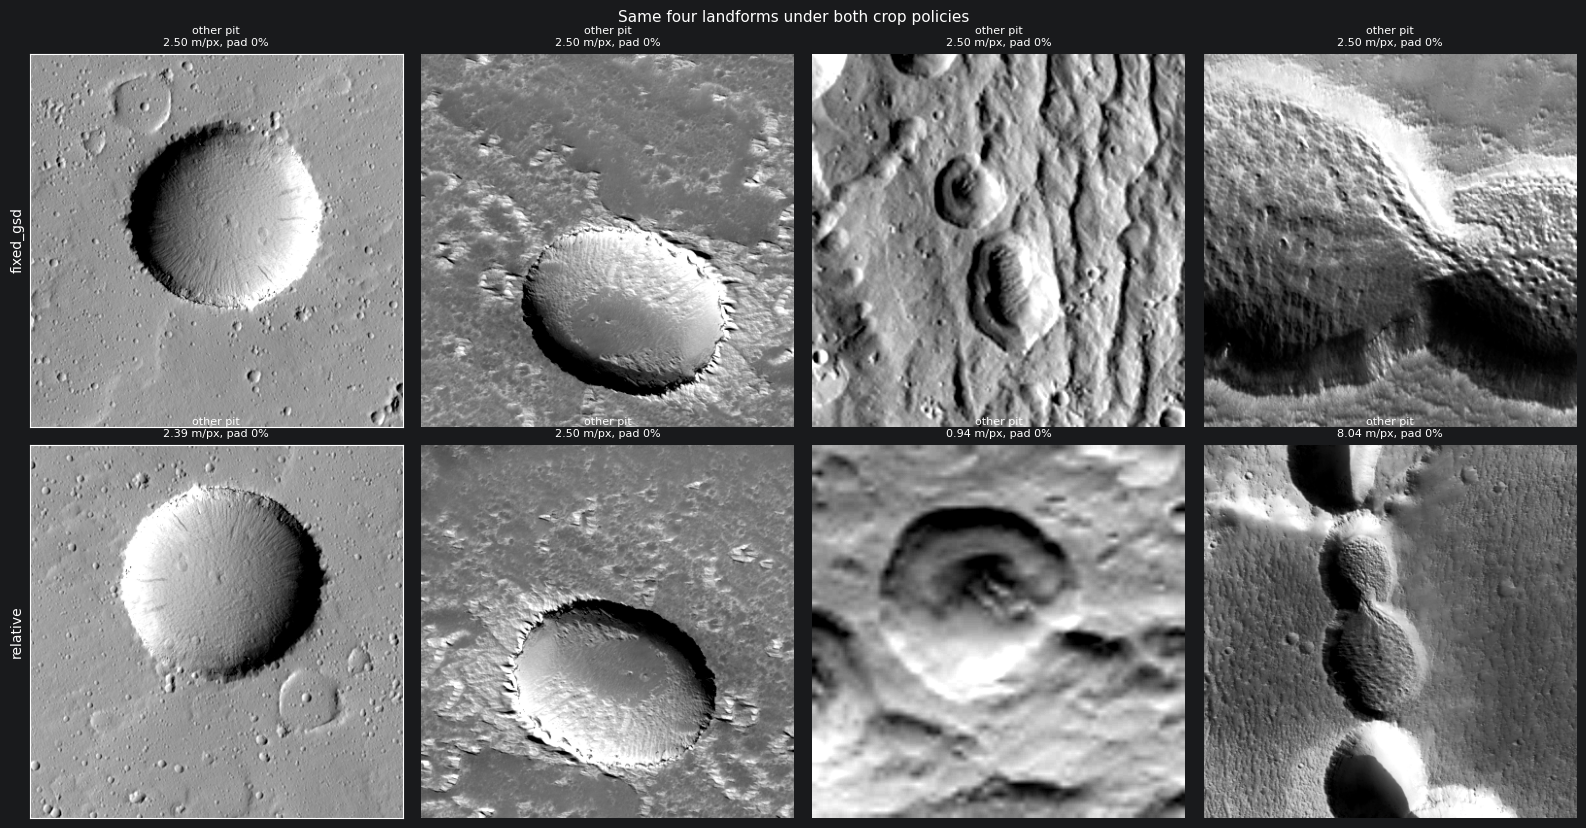

1407 train / 439 val samples
images   (8, 1, 384, 384)  torch.float32  range [0.00, 1.00]
thermals (8, 3, 2, 32, 32)  (real THEMIS; channel 0 temperature, channel 1 validity mask)
times    (8, 3, 5)  (sin/cos local solar time, sin/cos solar longitude, known flag)
         mask coverage in this batch: 0.81


In [3]:
sample_idx = [3, 40, 900, 1500]

fig, axs = plt.subplots(2, len(sample_idx), figsize=(4 * len(sample_idx), 8.4))
for r, policy in enumerate(CROP_POLICIES):
    preview = make_dataset("binary", policy, augment=True)
    for c, idx in enumerate(sample_idx):
        image, _, _, label = preview[idx]
        geometry = preview.crop_geometry(idx)
        axs[r, c].imshow(image.squeeze(0), cmap="gray")
        axs[r, c].set_title(
            f"{TASKS['binary']['names'][int(label)]}\n"
            f"{geometry['effective_gsd_m']:.2f} m/px, "
            f"pad {geometry['padded_fraction']:.0%}", fontsize=8)
        axs[r, c].axis("off")
    axs[r, 0].set_ylabel(policy)
    axs[r, 0].axis("on")
    axs[r, 0].set_xticks([])
    axs[r, 0].set_yticks([])
fig.suptitle("Same four landforms under both crop policies", fontsize=11)
plt.tight_layout()
plt.show()

# One batch, to confirm the shapes the model will actually be handed.
train_loader, val_loader = create_dataloaders(
    functools.partial(make_dataset, "binary", "fixed_gsd"),
    batch_size=8, num_workers=0, group_level=GROUP_LEVEL,
)
images, thermals, thermal_times, batch_targets = next(iter(train_loader))
print(f"{len(train_loader.dataset)} train / {len(val_loader.dataset)} val samples")
print(f"images   {tuple(images.shape)}  {images.dtype}  "
      f"range [{images.min():.2f}, {images.max():.2f}]")
print(f"thermals {tuple(thermals.shape)}  "
      f"({'real THEMIS' if USE_REAL_THERMAL else 'randn placeholder'}; "
      "channel 0 temperature, channel 1 validity mask)")
print(f"times    {tuple(thermal_times.shape)}  "
      "(sin/cos local solar time, sin/cos solar longitude, known flag)")
if USE_REAL_THERMAL:
    print(f"         mask coverage in this batch: {thermals[:, :, 1].mean():.2f}")

## Baselines: what is obtainable without morphology

A CNN score means nothing on its own. The baseline bar is *whatever this data set gives up without any shape
information at all*.

| baseline | what it may look at |
|---|---|
| `majority` | nothing; predicts the commonest training class |
| `geometry` | the crop **window**, not its contents: effective ground sampling distance and padded fraction |
| `histogram` | the crop's intensity histogram: moments, percentiles, dark/bright fractions, entropy |
| `texture` | the above plus gradient-magnitude statistics |
| `illumination` | solar incidence / emission / phase angle, season, local solar time of the source product |
| `availability` | thermal coverage bookkeeping, and not one Kelvin value |
| `metadata` (oracle) | resolution, tile size, annotated diameter, latitude, longitude |

**Why `histogram` is the honest bar.** Every feature in it is a function of the
*multiset* of pixel values, so it is invariant to permuting the pixels. Shuffle a
crop and its morphology is destroyed while these numbers do not move.

**Why `geometry` is the bar for the crop policy.** It is handed the window and
none of its pixels. Under `relative` the crop side is a multiple of the
annotation and is then resampled to a fixed pixel count, so the *resampling
factor* is a function of landform size -- and landform size is the strongest
class signal in this data set.

**`metadata` is a disclosure, not a result.** `diameter_m` comes from the
annotation itself, so no real detector would have it before detecting anything.

Features are extracted once per crop policy and cached; the first run of each
takes a few minutes.

In [4]:
from data.optical.hirise_metadata import product_geometry_table
from model.baselines import (availability_features, extract_image_features,
                             geometry_features, illumination_features,
                             run_baselines, texture_features)

# Solar geometry, fetched once per HiRISE product from PDS ODE and cached.
geometry = product_geometry_table(annotations["product"].dropna().unique())

# Thermal coverage bookkeeping and no temperature: the control for the
# multimodal claim. If "both" beats "optical" by no more than this beats the
# majority class, the gain is coverage, not physics. See data_overview section 7.
availability = availability_features(
    annotation_sites, "data/thermal/themis_data/window_manifest.json"
)

FEATURES = {}
for policy in CROP_POLICIES:
    cache = f"data/optical/final_data/baseline_features_{policy}.json"
    # Crops must be the ones the network sees at validation time: augment=False.
    baseline_dataset = make_dataset("binary", policy, augment=False)

    if os.path.exists(cache):
        texture = pd.read_json(cache)
        print(f"{policy:10s} loaded cached features {texture.shape}")
    else:
        texture = extract_image_features(baseline_dataset, texture_features)
        texture.to_json(cache)
        print(f"{policy:10s} extracted {texture.shape} -> {cache}")

    histogram = texture[[c for c in texture.columns if not c.startswith("grad_")]]

    FEATURES[policy] = {
        "geometry (crop window only)": geometry_features(baseline_dataset),
        "histogram (perm-invariant)": histogram,
        "texture (+gradients)": texture,
        "illumination": illumination_features(annotations, geometry),
    }
    if availability is not None:
        FEATURES[policy]["availability (no temperature)"] = availability
    else:
        print("  no thermal manifest for these sites; availability unavailable")

159 products, 159 cached, 0 to fetch
159/159 products carry an incidence angle
fixed_gsd  loaded cached features (1846, 27)
relative   loaded cached features (1846, 27)


In [5]:
# Every task, every crop policy, both grouping levels. Product-level is the
# honest column; landform-level is kept beside it so the leakage the product
# grouping removes is visible rather than assumed.
grouping_dataset = make_dataset("binary", "fixed_gsd", augment=False)
GROUPS = {level: grouping_dataset.group_keys(level=level)
          for level in ("landform", "product")}

baseline_tables = {}
for policy, level, task_name in itertools.product(
    CROP_POLICIES, ("landform", "product"), TASKS
):
    print()
    print(f"=== {task_name} | crops: {policy} | {level}-level groups "
          f"(n={len(set(GROUPS[level]))}) ===")
    baseline_tables[(policy, level, task_name)] = run_baselines(
        annotations, FEATURES[policy], GROUPS[level],
        labels=TASKS[task_name]["targets"],
    )


=== binary | crops: fixed_gsd | landform-level groups (n=318) ===
  majority             acc  66.1 +/-  0.3   F1  39.8 +/-  0.1
  geometry (crop window only) acc  69.9 +/-  0.3   F1  54.2 +/-  0.5
  histogram (perm-invariant) acc  79.1 +/-  2.2   F1  75.9 +/-  2.6
  texture (+gradients) acc  82.9 +/-  2.5   F1  80.6 +/-  2.9
  illumination         acc  77.7 +/-  3.8   F1  73.7 +/-  2.8
  availability (no temperature) acc  74.7 +/-  2.2   F1  69.2 +/-  2.9
  metadata (oracle)    acc  88.5 +/-  2.0   F1  86.8 +/-  2.4

=== 3class | crops: fixed_gsd | landform-level groups (n=318) ===
  majority             acc  35.6 +/-  0.4   F1  17.5 +/-  0.1
  geometry (crop window only) acc  39.9 +/-  0.5   F1  27.0 +/-  0.4
  histogram (perm-invariant) acc  60.1 +/-  2.7   F1  60.0 +/-  2.8
  texture (+gradients) acc  62.8 +/-  2.9   F1  62.6 +/-  3.2
  illumination         acc  65.9 +/-  5.5   F1  65.6 +/-  5.0
  availability (no temperature) acc  56.1 +/-  6.6   F1  56.0 +/-  6.4
  metadata (orac

Accuracy (%), product-level groups, mean over 5 folds:


,binary / fixed_gsd,3class / fixed_gsd,binary / relative,3class / relative
baseline,,,,
majority,66.1,35.6,66.1,35.6
geometry (crop window only),69.9,38.9,80.9,60.1
histogram (perm-invariant),77.8,57.8,88.7,68.9
texture (+gradients),81.7,59.3,89.4,71.6
illumination,59.6,39.0,59.6,39.0
availability (no temperature),64.8,41.7,64.8,41.7
metadata (oracle),84.3,64.6,84.3,64.6


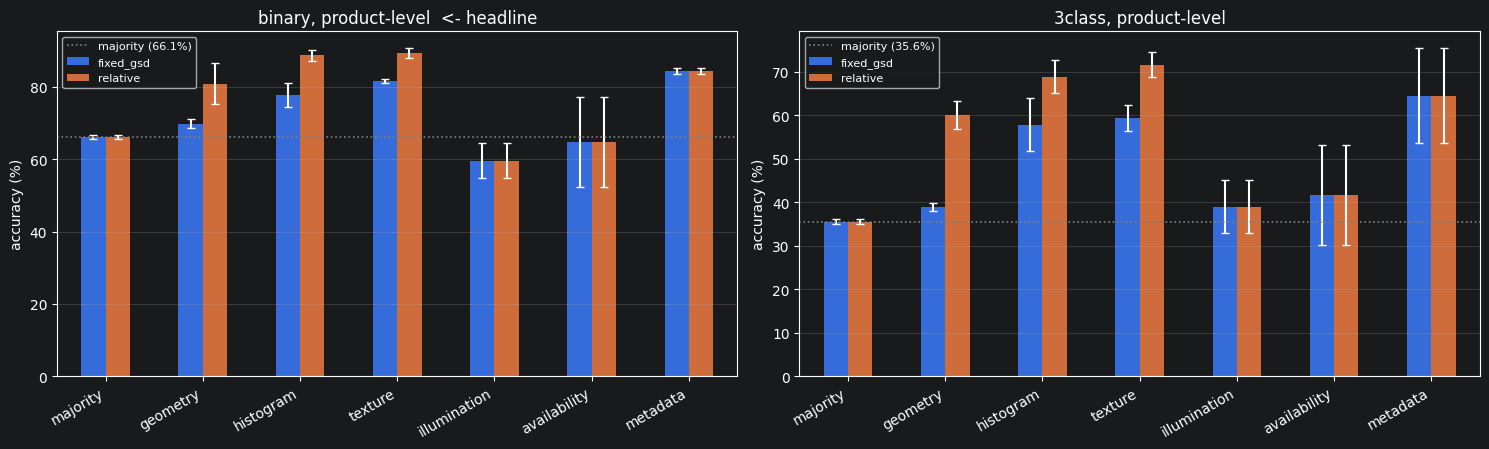

binary  bar for the CNN (product-level): fixed_gsd histogram 77.8%, window-only 69.9%   relative histogram 88.7%, window-only 80.9%
3class  bar for the CNN (product-level): fixed_gsd histogram 57.8%, window-only 38.9%   relative histogram 68.9%, window-only 60.1%


In [6]:
BAR = {                     # permutation-invariant image features
    (policy, task_name): baseline_tables[(policy, "product", task_name)].loc[
        "histogram (perm-invariant)", "acc_mean"]
    for policy in CROP_POLICIES for task_name in TASKS
}
GEOMETRY_BAR = {            # the crop window alone, no pixels
    (policy, task_name): baseline_tables[(policy, "product", task_name)].loc[
        "geometry (crop window only)", "acc_mean"]
    for policy in CROP_POLICIES for task_name in TASKS
}

summary = pd.DataFrame({
    f"{task_name} / {policy}": baseline_tables[(policy, "product", task_name)]["acc_mean"] * 100
    for policy in CROP_POLICIES for task_name in TASKS
}).round(1)
print("Accuracy (%), product-level groups, mean over 5 folds:")
display(summary)

# The baseline names carry a parenthetical saying what each may look at, which
# is what the table above is for. On an axis they collide: at seven categories
# across half a figure, "geometry (crop window only)" runs into
# "histogram (perm-invariant)" and two labels look like they are missing.
SHORT_NAMES = {
    "geometry (crop window only)": "geometry",
    "histogram (perm-invariant)": "histogram",
    "texture (+gradients)": "texture",
    "availability (no temperature)": "availability",
    "metadata (oracle)": "metadata",
}

fig, axs = plt.subplots(1, 2, figsize=(15, 4.6), sharey=False)
for ax, task_name in zip(axs, TASKS):
    frame = pd.DataFrame({
        policy: baseline_tables[(policy, "product", task_name)]["acc_mean"] * 100
        for policy in CROP_POLICIES
    })
    errs = pd.DataFrame({
        policy: baseline_tables[(policy, "product", task_name)]["acc_std"] * 100
        for policy in CROP_POLICIES
    })
    # Rename only for the axis; BAR and GEOMETRY_BAR are keyed on the full names.
    frame = frame.rename(index=SHORT_NAMES)
    errs = errs.rename(index=SHORT_NAMES)
    frame.plot.bar(ax=ax, yerr=errs, capsize=3, rot=0)
    # Anchored at the right end so a rotated label sits under its own bar
    # instead of drifting left of it.
    ax.set_xticklabels(frame.index, rotation=30, ha="right")
    ax.set_xlabel("")
    floor = TASKS[task_name]["majority"] * 100
    ax.axhline(floor, ls=":", c="grey", lw=1.2, label=f"majority ({floor:.1f}%)")
    ax.set_title(f"{task_name}, product-level"
                 + ("  <- headline" if task_name == "binary" else ""))
    ax.set_ylabel("accuracy (%)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

for task_name in TASKS:
    print(f"{task_name:7s} bar for the CNN (product-level): "
          + "   ".join(f"{policy} histogram {BAR[(policy, task_name)] * 100:.1f}%, "
                       f"window-only {GEOMETRY_BAR[(policy, task_name)] * 100:.1f}%"
                       for policy in CROP_POLICIES))

### Reading the baselines

**1. Product-level grouping is not optional.** `illumination` scores 65.9% on
3-class with landform-level groups and **39.0%** with product-level groups,
against a 35.6% majority. Solar geometry is constant within a HiRISE product, so
under the looser grouping the classifier is not learning physics, it is
memorising which product a crop came from. The same collapse hits `metadata`
(78.0% -> 64.6%). The image features barely move, which is the evidence that
they are *not* leaking site identity.

**2. The crop policy is a result in its own right.** Product-level, 5 folds:

| baseline | binary, `relative` | binary, `fixed_gsd` | 3-class, `relative` | 3-class, `fixed_gsd` |
|---|---|---|---|---|
| majority | 66.1% | 66.1% | 35.6% | 35.6% |
| **geometry (window only)** | **80.9%** | **69.9%** | **60.1%** | **38.9%** |
| histogram (perm-invariant) | 88.7% | **77.8%** | 68.9% | **57.8%** |
| texture (+gradients) | 89.4% | **81.7%** | 71.6% | **59.3%** |
| metadata (oracle) | 84.3% | 84.3% | 64.6% | 64.6% |

Under `relative`, median effective GSD is 0.71 m/pixel for Type-1 against 3.45
for Type-2: Type-1 crops arrive upsampled and smooth, Type-2 crops downsampled
and sharp. That is *visible in the pixels* -- gradient statistics recover the
effective GSD with out-of-group R^2 = 0.59, and even the permutation-invariant
histogram features recover it at R^2 = 0.24.

**Eleven points of the "honest bar" were the pipeline.** The histogram baseline
falls 88.7% -> 77.8% on binary and 68.9% -> 57.8% on 3-class; the geometry
control falls 80.9% -> 69.9% and 60.1% -> 38.9%, the last within 3.3 points of
the majority class. Same species of finding as section 8.1 of `data_overview`, reached
the same way: normalise one artefact and the next is exposed.

It also *opens headroom*. The bar is 77.8%, not 88.7%, so the room left for a
second modality goes from about 11 points to about 22.

**3. There is a mild but real illumination bias, and it should be disclosed.**
Median solar incidence is 43.1 deg for Type-1 against 55.2 for Type-4 and 51.7
for Type-2 (Kruskal-Wallis over the 159 products, p = 0.003). Out of product it
predicts nothing (59.6% against a 66.1% majority), but it is not nothing.

**4. `stretch_intensity` is load-bearing, and should be ablated rather than
assumed.** Measured on all 1846 crops under `fixed_gsd`, product-grouped, so
the stretched figure is the same number as the table above: the histogram
baseline reaches 77.8% binary with the stretch and **83.9% without** (3-class:
57.8% against 65.8%), and raw brightness alone -- mean, std, p02, p98 -- reaches
79.5%. Brightness is set by solar incidence and regional albedo, both
acquisition properties, so discarding it is the right default; but it also
flattens shadow *depth*, which is physically what a deep pit has. Report both
and say which the headline uses.

## Cross-validated modality ablation

Optical alone, thermal alone, both -- for every task, every crop policy and
three seeds. Everything below runs in one pass and caches as it goes.

**How to read it.**

* Splits are group-aware at **product** level, so no landform, no resolution
  replica and nothing sharing an acquisition can straddle a fold. That leaves
  127 groups.
* **Three seeds, not one.** With 127 groups a 5-fold split leaves ~25 groups per
  fold, and the fold-to-fold spread is comparable to every effect being
  measured. Five folds of one partition are not five independent samples of "how
  well does this do on unseen products" -- they are five slices of one way of
  cutting the data. Changing the seed re-partitions the groups *and*
  re-initialises the weights, so the spread across seeds captures both. Report
  the mean over seeds x folds, with the standard deviation of the **per-seed
  means** as the uncertainty on it.
* **The reported epoch is the last one, at a fixed budget.** `best_*` columns
  record the epoch that maximised validation F1, but that is a model selection
  made on the fold being scored. Measured over all 36 runs here it adds 3.8
  accuracy points for optical, 5.0 for thermal and 4.2 for fusion -- 4.1, 5.8
  and 4.8 in macro F1 -- always upwards, with the best epoch landing as early as
  epoch 1 of 8. The `histogram` baseline has no epochs and gets no such
  selection, so quoting best-epoch CNNs against it charges the whole bias to one
  side.
* **Checkpoints track macro F1, not accuracy.** Both tasks are imbalanced -- 34%
  skylights on binary -- and a model drifting towards the majority class gains
  accuracy while getting worse at the thing being detected. One checkpoint per
  run, from whichever fold scored highest, written to `model/checkpoints`.
* `collect_oof=True` predicts every sample exactly once, from the fold that did
  not train on it, so the confusion matrices cover the whole data set rather
  than one fold. Taken from the final epoch, so they agree with the table.
* With `USE_REAL_THERMAL = False` the thermal sequence is `torch.randn`, so
  **"thermal" must land at the majority class and "both" must not beat
  "optical"**. Anything else is a bug, not a discovery.
* With real windows, read "both" against **three** floors: `geometry`,
  `histogram` and `availability`. A gain smaller than the availability lift is
  coverage bookkeeping rather than physics; a gain that disappears under
  `fixed_gsd` was resampling rather than morphology.
* Expect the thermal contribution to be small. 302 of 314 sites carry a full
  three-frame sequence, but only 82 of 2588 available observations (3.2%,
  covering 75 of 314 sites) fall in the 02-06 h pre-dawn window where Cushing's
  contrast is maximal; 92% of the archive over these sites sits in two narrow
  terminator clusters at ~07 h and ~19 h, whose measured day/night separation is
  7 K against the >20 K of the terrestrial analogue.

**Cost.** 2 tasks x 2 policies x 3 modalities x 3 seeds x 5 folds x 8 epochs =
360 fold-trainings. At 4 dataloader workers that is roughly **8 hours** on one
GPU -- about 17 min per optical or fused run and 4 min per thermal one, so ~40
min per (task, policy, seed). With `CV_WORKERS = 0` it is closer to three days,
because crop decoding rather than the GPU is the bottleneck.

Checkpoints add about **1.14 GB**: one file per run, 45 MB for optical, 48 MB
for the fused model and 4 MB for thermal-only.

The grid is ordered so the runs the paper needs most finish first, and every one
is cached the moment it completes -- interrupt and re-execute freely. Trim
`EXPERIMENTS` or `SEEDS` if that is more than you want to spend; the headline
needs only the first row.

In [7]:
# Ordered by how much the paper depends on the result. Cached as each finishes,
# so interrupting costs only the run in flight.
EXPERIMENTS = [
    ("binary", "fixed_gsd"),   # headline
    ("3class", "fixed_gsd"),   # secondary result
    ("binary", "relative"),    # quantifies the resampling artefact
    ("3class", "relative"),
]

RUN_CV = True

criterion = nn.CrossEntropyLoss()

# The binary task is imbalanced (34% skylights). Average precision, reported
# below, is threshold-free and unaffected; class weights only move where the
# argmax boundary sits, and macro F1 already refuses to reward drifting towards
# the majority class. Left off, and named so it can be turned on deliberately.
CLASS_WEIGHTS = False


def run_key(task_name, policy, modality, seed):
    return os.path.join(CV_CACHE, f"{task_name}_{policy}_{modality}_seed{seed}")


# Recorded next to every cached run. The cache key is task/policy/modality/seed
# only, so without this, changing the epoch budget or the crop footprint would
# silently mix old and new runs into one table. load_run compares them and
# recomputes anything that no longer matches.
RUN_CONFIG = dict(
    footprint_m=FOOTPRINT_M, out_gsd_m=OUT_GSD_M,
    context=CONTEXT, out_px=OUT_PX,
    thermal_window=THERMAL_WINDOW,
    use_real_thermal=USE_REAL_THERMAL, use_thermal_time=USE_THERMAL_TIME,
    cv_folds=CV_FOLDS, epochs=CV_EPOCHS, group_level=GROUP_LEVEL,
    batch_size=8, learning_rate=1e-4,
)


cv_folds, cv_oof = {}, {}
started = time.time()

for task_name, policy in EXPERIMENTS:
    task = TASKS[task_name]

    for modality in MODALITIES:
        frames, per_seed_oof = [], {}

        for seed in SEEDS:
            stem = run_key(task_name, policy, modality, seed)

            restored = load_run(stem, RUN_CONFIG)
            if restored is not None:
                per_fold, oof = restored
                frames.append(per_fold.reset_index().assign(seed=seed))
                per_seed_oof[seed] = oof
                print(f"{task_name}/{policy}/{modality}/seed{seed}: cached")
                continue

            if not RUN_CV:
                print(f"{task_name}/{policy}/{modality}/seed{seed}: "
                      "not cached, and RUN_CV is False")
                continue

            print()
            print("#" * 70)
            print(f"# {task_name} | {policy} | {modality} | seed {seed}"
                  f"   [{(time.time() - started) / 60:.0f} min elapsed]")
            print("#" * 70)

            # Skip decoding the crops entirely when they will not be used.
            factory = functools.partial(
                make_dataset, task_name, policy,
                load_optical=(modality != "thermal"),
            )

            per_fold, _, oof_targets, oof_probs = cross_validate(
                dataset_factory=lambda augment, f=factory: f(augment),
                model_factory=functools.partial(
                    LavaTubeFinder, n_classes=task["n_classes"],
                    modality=modality, thermal_window=THERMAL_WINDOW,
                    use_thermal_time=USE_THERMAL_TIME,
                ),
                criterion=criterion,
                optimizer_factory=lambda m: torch.optim.Adam(m.parameters(), lr=1e-4),
                num_epochs=CV_EPOCHS,
                device=DEVICE,
                n_splits=CV_FOLDS,
                batch_size=8,
                num_workers=CV_WORKERS,
                seed=seed,
                group_level=GROUP_LEVEL,
                collect_oof=True,
                checkpoint_path=os.path.join(
                    CHECKPOINT_DIR,
                    f"{task_name}_{policy}_{modality}_seed{seed}.pt"),
                checkpoint_metric=CHECKPOINT_METRIC,
            )

            save_run(stem, per_fold, oof_targets, oof_probs, RUN_CONFIG)
            frames.append(per_fold.reset_index().assign(seed=seed))
            per_seed_oof[seed] = (oof_targets, oof_probs)

            if DEVICE.type == "cuda":
                torch.cuda.empty_cache()

        if frames:
            cv_folds[(task_name, policy, modality)] = (
                pd.concat(frames, ignore_index=True)
                .set_index(["seed", "fold"]).sort_index()
            )
            cv_oof[(task_name, policy, modality)] = per_seed_oof

print()
print(f"{len(cv_folds)} runs available after {(time.time() - started) / 60:.0f} min")

  binary_fixed_gsd_optical_seed42: cached before settings were recorded; assuming it matches
binary/fixed_gsd/optical/seed42: cached
  binary_fixed_gsd_optical_seed43: cached before settings were recorded; assuming it matches
binary/fixed_gsd/optical/seed43: cached
  binary_fixed_gsd_optical_seed44: cached before settings were recorded; assuming it matches
binary/fixed_gsd/optical/seed44: cached
  binary_fixed_gsd_thermal_seed42: cached before settings were recorded; assuming it matches
binary/fixed_gsd/thermal/seed42: cached
  binary_fixed_gsd_thermal_seed43: cached before settings were recorded; assuming it matches
binary/fixed_gsd/thermal/seed43: cached
  binary_fixed_gsd_thermal_seed44: cached before settings were recorded; assuming it matches
binary/fixed_gsd/thermal/seed44: cached
  binary_fixed_gsd_both_seed42: cached before settings were recorded; assuming it matches
binary/fixed_gsd/both/seed42: cached
  binary_fixed_gsd_both_seed43: cached before settings were recorded; assum

### Results

`mean` is over all seeds x folds. `sd(seed)` is the standard deviation of the
per-seed means -- the uncertainty on that mean. `sd(fold)` is the spread across
individual folds, which is larger and is the reason a single split cannot
resolve the effects being measured.

In [8]:
def summarise(frame, metric="val_f1"):
    per_seed = frame.groupby("seed")[metric].mean()
    return {
        "mean": frame[metric].mean() * 100,
        "sd(seed)": per_seed.std() * 100,
        "sd(fold)": frame[metric].std() * 100,
    }


for task_name, policy in EXPERIMENTS:
    present = {m: cv_folds[(task_name, policy, m)] for m in MODALITIES
               if (task_name, policy, m) in cv_folds}
    if not present:
        continue

    print()
    print(f"=== {task_name} | crops: {policy} | {len(SEEDS)} seeds x "
          f"{CV_FOLDS} folds, final epoch ===")

    table = pd.DataFrame({
        modality: {
            **{f"{m.replace('val_', '')} {k}": v
               for m in ("val_acc", "val_f1")
               for k, v in summarise(frame, m).items()},
        }
        for modality, frame in present.items()
    }).T.round(2)
    display(table)

    print(f"floors: majority {TASKS[task_name]['majority'] * 100:.1f}%   "
          f"window-only {GEOMETRY_BAR[(policy, task_name)] * 100:.1f}%   "
          f"histogram {BAR[(policy, task_name)] * 100:.1f}%")


=== binary | crops: fixed_gsd | 3 seeds x 5 folds, final epoch ===


,acc mean,acc sd(seed),acc sd(fold),f1 mean,f1 sd(seed),f1 sd(fold)
optical,91.28,0.36,4.62,90.42,0.25,4.75
thermal,65.87,2.13,6.02,62.23,2.89,6.51
both,88.43,1.69,4.89,87.12,2.03,5.22


floors: majority 66.1%   window-only 69.9%   histogram 77.8%

=== 3class | crops: fixed_gsd | 3 seeds x 5 folds, final epoch ===


,acc mean,acc sd(seed),acc sd(fold),f1 mean,f1 sd(seed),f1 sd(fold)
optical,75.96,0.32,6.07,74.79,0.26,6.28
thermal,47.52,2.66,5.45,46.59,2.64,5.50
both,69.80,2.69,9.51,68.76,2.98,9.36


floors: majority 35.6%   window-only 38.9%   histogram 57.8%

=== binary | crops: relative | 3 seeds x 5 folds, final epoch ===


,acc mean,acc sd(seed),acc sd(fold),f1 mean,f1 sd(seed),f1 sd(fold)
optical,92.31,0.30,3.89,91.36,0.43,4.48
thermal,65.87,2.13,6.02,62.23,2.89,6.51
both,91.01,1.50,3.06,89.84,1.67,3.44


floors: majority 66.1%   window-only 80.9%   histogram 88.7%

=== 3class | crops: relative | 3 seeds x 5 folds, final epoch ===


,acc mean,acc sd(seed),acc sd(fold),f1 mean,f1 sd(seed),f1 sd(fold)
optical,79.28,2.90,4.32,78.35,3.23,4.39
thermal,47.52,2.66,5.45,46.59,2.64,5.50
both,76.23,1.02,4.43,74.78,0.74,4.77


floors: majority 35.6%   window-only 60.1%   histogram 68.9%


In [9]:
# Fusion against optical, paired on the same (seed, fold). Two overlapping error
# bars cannot resolve an effect this size; the paired spread can.
from scipy import stats

rows = []
for task_name, policy in EXPERIMENTS:
    key_both = (task_name, policy, "both")
    key_optical = (task_name, policy, "optical")
    if key_both not in cv_folds or key_optical not in cv_folds:
        continue

    paired = cv_folds[key_both]["val_f1"].sub(cv_folds[key_optical]["val_f1"])
    delta = paired.dropna() * 100
    half = stats.t.ppf(0.975, len(delta) - 1) * delta.std() / len(delta) ** 0.5
    rows.append({
        "task": task_name,
        "crops": policy,
        "n pairs": len(delta),
        "mean dF1 (pts)": delta.mean(),
        "CI low": delta.mean() - half,
        "CI high": delta.mean() + half,
        "p (paired t)": stats.ttest_rel(
            cv_folds[key_both]["val_f1"], cv_folds[key_optical]["val_f1"]).pvalue,
    })

if rows:
    print("both - optical, paired across every (seed, fold):")
    display(pd.DataFrame(rows).set_index(["task", "crops"]).round(3))
    print("A confidence interval that contains zero and excludes anything large")
    print("is a result: it bounds how much fusion could be helping.")

both - optical, paired across every (seed, fold):


,,n pairs,mean dF1 (pts),CI low,CI high,p (paired t)
task,crops,,,,,
binary,fixed_gsd,15,-3.300,-5.592,-1.008,0.008
3class,fixed_gsd,15,-6.031,-10.854,-1.208,0.018
binary,relative,15,-1.517,-3.238,0.203,0.079
3class,relative,15,-3.573,-6.920,-0.226,0.038


A confidence interval that contains zero and excludes anything large
is a result: it bounds how much fusion could be helping.


In [10]:
# What best-epoch selection would have added, so its size is visible rather
# than taken on trust.
rows = []
for (task_name, policy, modality), frame in cv_folds.items():
    if "best_val_f1" not in frame.columns:
        continue
    rows.append({
        "task": task_name, "crops": policy, "modality": modality,
        "final F1": frame["val_f1"].mean() * 100,
        "best-epoch F1": frame["best_val_f1"].mean() * 100,
        "optimism (pts)": (frame["best_val_f1"] - frame["val_f1"]).mean() * 100,
        "median best epoch": frame["best_epoch"].median(),
    })

if rows:
    print("Selecting the best epoch on the validation fold would add:")
    display(pd.DataFrame(rows)
            .set_index(["task", "crops", "modality"]).round(2))

Selecting the best epoch on the validation fold would add:


final F1  best-epoch F1  optimism (pts)  \
task   crops     modality                                            
binary fixed_gsd optical      90.42          92.94            2.51   
                 thermal      62.23          69.02            6.79   
                 both         87.12          91.26            4.14   
3class fixed_gsd optical      74.79          79.53            4.74   
                 thermal      46.59          51.44            4.86   
                 both         68.76          73.95            5.20   
binary relative  optical      91.36          94.43            3.07   
                 thermal      62.23          69.02            6.79   
                 both         89.84          93.98            4.14   
3class relative  optical      78.35          84.36            6.01   
                 thermal      46.59          51.44            4.86   
                 both         74.78          80.54            5.77   

                           median best epoch  
task   crops     modality                     
binary fixed_gsd optical                 6.0  
                 thermal                 5.0  
                 both                    4.0  
3class fixed_gsd optical                 6.0  
                 thermal                 6.0  
                 both                    5.0  
binary relative  optical                 6.0  
                 thermal                 5.0  
                 both                    3.0  
3class relative  optical                 6.0  
                 thermal                 6.0  
                 both                    4.0

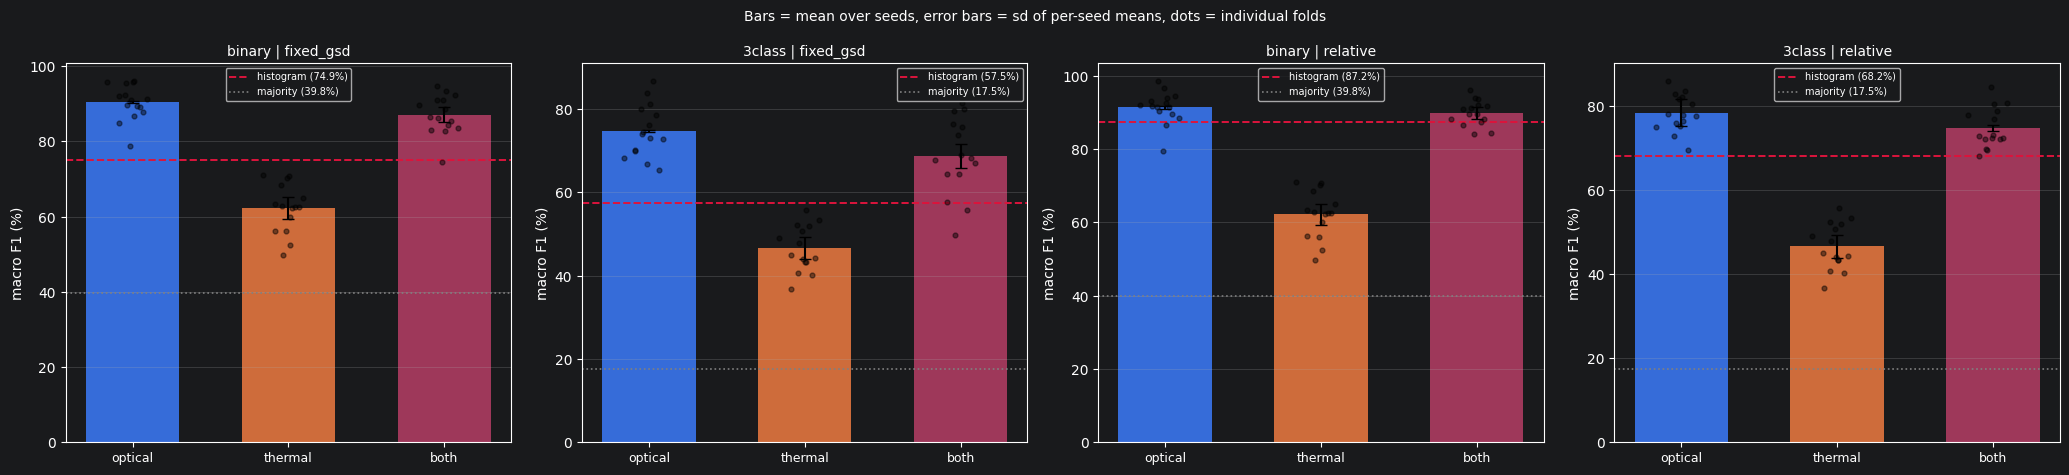

In [11]:
n_panels = len([1 for e in EXPERIMENTS
                if any((e[0], e[1], m) in cv_folds for m in MODALITIES)])
fig, axs = plt.subplots(1, max(n_panels, 1),
                        figsize=(5.2 * max(n_panels, 1), 4.8), squeeze=False)

panel = 0
for task_name, policy in EXPERIMENTS:
    present = {m: cv_folds[(task_name, policy, m)] for m in MODALITIES
               if (task_name, policy, m) in cv_folds}
    if not present:
        continue
    ax = axs[0, panel]
    panel += 1

    for offset, (modality, frame) in enumerate(present.items()):
        per_seed = frame.groupby("seed")["val_f1"].mean() * 100
        ax.bar(offset, per_seed.mean(), 0.6, yerr=per_seed.std(), capsize=4,
               color=f"C{offset}")
        # Every fold, so the reader sees the raw spread and not only a bar.
        ax.scatter(np.full(len(frame), offset)
                   + np.random.default_rng(0).normal(0, 0.07, len(frame)),
                   frame["val_f1"] * 100, s=12, c="black", alpha=0.45, zorder=3)

    ax.set_xticks(range(len(present)))
    ax.set_xticklabels(list(present), fontsize=9)
    # These bars are macro F1, so the reference lines have to be macro F1 too.
    # BAR and GEOMETRY_BAR are accuracies, and TASKS[...]["majority"] is the
    # majority class *rate* -- drawing any of them here would put the line tens
    # of points off. A majority classifier scores 66.1% accuracy on the binary
    # task but only 39.8% macro F1, because it never predicts the other class.
    reference = baseline_tables[(policy, "product", task_name)]["f1_mean"]
    for name, style, colour, width in (
        ("histogram (perm-invariant)", "--", "crimson", 1.4),
        ("majority", ":", "grey", 1.2),
    ):
        ax.axhline(reference[name] * 100, ls=style, c=colour, lw=width,
                   label=f"{name.split(' (')[0]} ({reference[name]:.1%})")
    ax.set_title(f"{task_name} | {policy}", fontsize=10)
    ax.set_ylabel("macro F1 (%)")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3, axis="y")

fig.suptitle("Bars = mean over seeds, error bars = sd of per-seed means, "
             "dots = individual folds", fontsize=10)
plt.tight_layout()
plt.show()

### Out-of-fold detector readout

Every sample scored by a model that never saw it. Reported per seed, because
pooling probabilities from differently-calibrated runs would blur exactly the
variability the three seeds exist to measure.

In [12]:
from sklearn.metrics import classification_report, confusion_matrix

for task_name, policy in EXPERIMENTS:
    task = TASKS[task_name]
    for modality in MODALITIES:
        key = (task_name, policy, modality)
        if key not in cv_oof or not cv_oof[key]:
            continue

        print()
        print("=" * 70)
        print(f"{task_name} | {policy} | {modality}")
        print("=" * 70)

        if task["positive"] is not None:
            scores = []
            for seed, (targets, probs) in cv_oof[key].items():
                result = binary_report(targets, probs, positive=task["positive"],
                                       verbose=False)
                scores.append({"seed": seed, **result})
            frame = pd.DataFrame(scores).set_index("seed")
            display(frame.round(3))
            print(f"average precision {frame['average_precision'].mean():.3f} "
                  f"+/- {frame['average_precision'].std():.3f}   "
                  f"(a constant 'always skylight' scores "
                  f"{frame['positive_rate'].iloc[0]:.3f})")

            # One confusion matrix, from the first seed, for a concrete look.
            targets, probs = cv_oof[key][SEEDS[0]]
            predictions = (probs[:, task["positive"]] >= 0.5).astype(int)
            print(f"confusion, seed {SEEDS[0]} (rows=true, cols=pred):")
            print(confusion_matrix(targets, predictions))
        else:
            names = [task["names"][i] for i in range(task["n_classes"])]
            targets, probs = cv_oof[key][SEEDS[0]]
            print(f"seed {SEEDS[0]}:")
            print(classification_report(targets, probs.argmax(1),
                                        target_names=names, digits=3,
                                        zero_division=0))
            print(pd.DataFrame(confusion_matrix(targets, probs.argmax(1)),
                               index=names, columns=names).to_string())


binary | fixed_gsd | optical


,precision,recall,f1,average_precision,accuracy,positive_rate
seed,,,,,,
42,0.876,0.874,0.875,0.928,0.915,0.339
43,0.848,0.910,0.878,0.925,0.914,0.339
44,0.839,0.906,0.871,0.865,0.909,0.339


average precision 0.906 +/- 0.035   (a constant 'always skylight' scores 0.339)
confusion, seed 42 (rows=true, cols=pred):
[[1144   77]
 [  79  546]]

binary | fixed_gsd | thermal


,precision,recall,f1,average_precision,accuracy,positive_rate
seed,,,,,,
42,0.462,0.480,0.471,0.474,0.634,0.339
43,0.515,0.592,0.551,0.549,0.673,0.339
44,0.511,0.544,0.527,0.521,0.669,0.339


average precision 0.515 +/- 0.038   (a constant 'always skylight' scores 0.339)
confusion, seed 42 (rows=true, cols=pred):
[[871 350]
 [325 300]]

binary | fixed_gsd | both


...

average precision 0.952 +/- 0.004   (a constant 'always skylight' scores 0.339)
confusion, seed 42 (rows=true, cols=pred):
[[1149   72]
 [  69  556]]

binary | relative | thermal


,precision,recall,f1,average_precision,accuracy,positive_rate
seed,,,,,,
42,0.462,0.480,0.471,0.474,0.634,0.339
43,0.515,0.592,0.551,0.549,0.673,0.339
44,0.511,0.544,0.527,0.521,0.669,0.339


average precision 0.515 +/- 0.038   (a constant 'always skylight' scores 0.339)
confusion, seed 42 (rows=true, cols=pred):
[[871 350]
 [325 300]]

binary | relative | both


,precision,recall,f1,average_precision,accuracy,positive_rate
seed,,,,,,
42,0.924,0.856,0.889,0.904,0.927,0.339
43,0.854,0.851,0.853,0.868,0.900,0.339
44,0.886,0.818,0.850,0.901,0.902,0.339


average precision 0.891 +/- 0.020   (a constant 'always skylight' scores 0.339)
confusion, seed 42 (rows=true, cols=pred):
[[1177   44]
 [  90  535]]

3class | relative | optical
seed 42:
                       precision    recall  f1-score   support

Vertical Pit/Skylight      0.845     0.931     0.886       625
  Aligned Shallow Pit      0.721     0.760     0.740       657
           Sloped Pit      0.703     0.580     0.636       564

             accuracy                          0.763      1846
            macro avg      0.756     0.757     0.754      1846
         weighted avg      0.757     0.763     0.757      1846

                       Vertical Pit/Skylight  Aligned Shallow Pit  Sloped Pit
Vertical Pit/Skylight                    582                   23          20
Aligned Shallow Pit                       40                  499         118
Sloped Pit                                67                  170         327

3class | relative | thermal
seed 42:
                  

## The noise control: is the fusion penalty about THEMIS, or about fusing?

The ablation says adding the thermal branch *costs* macro F1 -- 3.30 points on
the headline task, 95% CI [-5.59, -1.01], p = 0.008. That is a clean result, but
on its own it does not say **why**, and the two explanations lead to different
sentences in the paper:

**(a) It is the architecture.** The fusion head has a fixed width and the
classifier sees `fusion_dim * n_streams`. Adding any second stream spends
capacity and adds parameters to fit, and with 127 independent groups that costs
something whatever the stream contains. Under this explanation the right
sentence is *"late fusion is not free at this sample size"* -- a statement about
method, not about Mars.

**(b) It is the data.** THEMIS is not merely uninformative but actively
misleading: the branch finds structure that correlates with class in training
and does not generalise, so it drags the fused model further down than noise
would. Under this explanation the sentence is *"the thermal archive is worse
than nothing for this task"*, which is a much stronger claim and needs this
control to support it.

The control separates them. Same architecture, same parameter count, same
schedule -- but the thermal branch receives `torch.randn` instead of retrieved
windows, and its time vector is all zeros with the known-flag cleared, so the
model can tell it was told nothing.

Then compare, paired on the same (seed, fold):

* `both(randn) - optical` -- the cost of bolting on an uninformative stream;
* `both(THEMIS) - optical` -- the cost we actually measured.

**If the two are the same, the answer is (a)** and the penalty says nothing
about THEMIS. **If THEMIS is reliably worse than noise, the answer is (b).**

`thermal(randn)` is run too, as the floor check the ablation section promises:
a branch fed pure noise must land at the majority class, and anything else means
the label is reaching the model through a path that is not the input.

Cached under its own `_randn` key, so it can never overwrite a real run. About
an hour: three seeds of `both` at ~17 min and three of `thermal` at ~4 min.

In [13]:
RUN_NOISE_CONTROL = True

# binary / fixed_gsd only: it is the headline, and the question is about the
# headline's negative result. Running the other three cells would triple the
# cost to answer the same question.
NOISE_TASK, NOISE_POLICY = "binary", "fixed_gsd"
NOISE_MODALITIES = ("both", "thermal")


def make_noise_dataset(augment, load_optical=True):
    """As make_dataset, but the thermal branch is handed torch.randn.

    thermal_dir=None is what switches LandformDataset to the placeholder, and
    with no thermal_times the time vector is zeros with its known-flag cleared
    -- so the model is told 'no measurement' rather than 'midnight'.
    """
    return LandformDataset(
        TASKS[NOISE_TASK]["annotations"], root_dir=".", augment=augment,
        load_optical=load_optical, crop_policy=NOISE_POLICY,
        out_px=OUT_PX, context=CONTEXT,
        footprint_m=FOOTPRINT_M, out_gsd_m=OUT_GSD_M,
        cache_crops=not augment,
        thermal_window=THERMAL_WINDOW,
    )


# use_real_thermal=False is what makes this config incompatible with the real
# runs; the separate _randn key means the two can never collide on disk.
NOISE_CONFIG = dict(RUN_CONFIG, use_real_thermal=False, use_thermal_time=False)

noise_folds, noise_oof = {}, {}
started = time.time()

for modality in NOISE_MODALITIES:
    frames, per_seed_oof = [], {}

    for seed in SEEDS:
        stem = run_key(NOISE_TASK, NOISE_POLICY, modality, seed) + "_randn"

        restored = load_run(stem, NOISE_CONFIG)
        if restored is not None:
            per_fold, oof = restored
            frames.append(per_fold.reset_index().assign(seed=seed))
            per_seed_oof[seed] = oof
            print(f"randn/{modality}/seed{seed}: cached")
            continue

        if not RUN_NOISE_CONTROL:
            print(f"randn/{modality}/seed{seed}: not cached, control disabled")
            continue

        print()
        print("#" * 70)
        print(f"# NOISE CONTROL | {modality} | seed {seed}"
              f"   [{(time.time() - started) / 60:.0f} min elapsed]")
        print("#" * 70)

        factory = functools.partial(
            make_noise_dataset, load_optical=(modality != "thermal")
        )

        per_fold, _, oof_targets, oof_probs = cross_validate(
            dataset_factory=lambda augment, f=factory: f(augment),
            model_factory=functools.partial(
                LavaTubeFinder, n_classes=TASKS[NOISE_TASK]["n_classes"],
                modality=modality, thermal_window=THERMAL_WINDOW,
                # Kept True so the architecture is identical to the real runs:
                # same parameters, uninformative input. That is the point.
                use_thermal_time=True,
            ),
            criterion=criterion,
            optimizer_factory=lambda m: torch.optim.Adam(m.parameters(), lr=1e-4),
            num_epochs=CV_EPOCHS, device=DEVICE, n_splits=CV_FOLDS,
            batch_size=8, num_workers=CV_WORKERS, seed=seed,
            group_level=GROUP_LEVEL, collect_oof=True,
            checkpoint_path=None,      # a noise model is not worth 45 MB
            checkpoint_metric=CHECKPOINT_METRIC,
        )

        save_run(stem, per_fold, oof_targets, oof_probs, NOISE_CONFIG)
        frames.append(per_fold.reset_index().assign(seed=seed))
        per_seed_oof[seed] = (oof_targets, oof_probs)

        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

    if frames:
        noise_folds[modality] = (pd.concat(frames, ignore_index=True)
                                 .set_index(["seed", "fold"]).sort_index())
        noise_oof[modality] = per_seed_oof

print()
print(f"{len(noise_folds)} noise-control arms available "
      f"after {(time.time() - started) / 60:.0f} min")

randn/both/seed42: cached
randn/both/seed43: cached
randn/both/seed44: cached
randn/thermal/seed42: cached
randn/thermal/seed43: cached
randn/thermal/seed44: cached

2 noise-control arms available after 0 min


In [14]:
optical = cv_folds.get((NOISE_TASK, NOISE_POLICY, "optical"))

if not noise_folds:
    print("No noise-control runs yet -- set RUN_NOISE_CONTROL = True above.")
elif optical is None:
    # The control is a *comparison*, so it needs the arm it compares against.
    # Run the ablation cell first; it loads from cache in seconds.
    print(f"The {NOISE_TASK} / {NOISE_POLICY} optical run is not loaded, and "
          "the control is meaningless without it.")
    print("Run the ablation cell above first -- it restores from cache.")
else:
    from scipy import stats

    real_both = cv_folds.get((NOISE_TASK, NOISE_POLICY, "both"))

    def paired(a, b, label):
        """Mean difference, CI and p for two arms on the same (seed, fold)."""
        common = a.index.intersection(b.index)
        delta = (a.loc[common, "val_f1"] - b.loc[common, "val_f1"]) * 100
        half = stats.t.ppf(0.975, len(delta) - 1) * delta.std() / len(delta) ** 0.5
        return {
            "comparison": label, "pairs": len(delta),
            "delta F1 (points)": round(delta.mean(), 2),
            "95% CI": f"[{delta.mean() - half:+.2f}, {delta.mean() + half:+.2f}]",
            "p": round(stats.ttest_rel(a.loc[common, "val_f1"],
                                       b.loc[common, "val_f1"]).pvalue, 3),
        }

    rows = []
    if "both" in noise_folds:
        rows.append(paired(noise_folds["both"], optical, "both(randn) - optical"))
    if real_both is not None:
        rows.append(paired(real_both, optical, "both(THEMIS) - optical"))
    if "both" in noise_folds and real_both is not None:
        rows.append(paired(real_both, noise_folds["both"],
                           "both(THEMIS) - both(randn)"))

    print(f"Fusion cost, {NOISE_TASK} / {NOISE_POLICY}, paired on (seed, fold):")
    display(pd.DataFrame(rows).set_index("comparison"))
    print()
    print("Read the third row. If its interval contains zero, THEMIS is")
    print("indistinguishable from noise and the penalty belongs to the fusion")
    print("head, not to the archive -- claim (a). If it is reliably below zero,")
    print("THEMIS is worse than noise -- claim (b).")

    # The floor check the ablation section promises.
    if "thermal" in noise_folds:
        acc = noise_folds["thermal"].groupby("seed")["val_acc"].mean() * 100
        floor = TASKS[NOISE_TASK]["majority"] * 100
        print()
        print(f"thermal(randn): {acc.mean():.1f} +/- {acc.std():.2f}% accuracy "
              f"against a {floor:.1f}% majority "
              f"({acc.mean() - floor:+.1f} points).")
        print("A branch fed pure noise must sit at the majority class. If it")
        print("does not, the label is reaching the model by some path that is")
        print("not the input, and every other number here is suspect.")

    summary = []
    for name, frame in (("optical", optical),
                        ("both (THEMIS)", real_both),
                        ("both (randn)", noise_folds.get("both")),
                        ("thermal (THEMIS)",
                         cv_folds.get((NOISE_TASK, NOISE_POLICY, "thermal"))),
                        ("thermal (randn)", noise_folds.get("thermal"))):
        if frame is None:
            continue
        acc = frame.groupby("seed")["val_acc"].mean() * 100
        f1 = frame.groupby("seed")["val_f1"].mean() * 100
        summary.append({"arm": name,
                        "accuracy": f"{acc.mean():.1f} +/- {acc.std():.2f}",
                        "macro F1": f"{f1.mean():.1f} +/- {f1.std():.2f}"})
    print()
    display(pd.DataFrame(summary).set_index("arm"))


Fusion cost, binary / fixed_gsd, paired on (seed, fold):


,pairs,delta F1 (points),95% CI,p
comparison,,,,
both(randn) - optical,15,1.13,"[-0.59, +2.85]",0.180
both(THEMIS) - optical,15,-3.30,"[-5.59, -1.01]",0.008
both(THEMIS) - both(randn),15,-4.43,"[-6.71, -2.15]",0.001



Read the third row. If its interval contains zero, THEMIS is
indistinguishable from noise and the penalty belongs to the fusion
head, not to the archive -- claim (a). If it is reliably below zero,
THEMIS is worse than noise -- claim (b).

thermal(randn): 66.1 +/- 0.03% accuracy against a 66.1% majority (-0.0 points).
A branch fed pure noise must sit at the majority class. If it
does not, the label is reaching the model by some path that is
not the input, and every other number here is suspect.



,accuracy,macro F1
arm,,
optical,91.3 +/- 0.36,90.4 +/- 0.25
both (THEMIS),88.4 +/- 1.69,87.1 +/- 2.03
both (randn),92.3 +/- 0.57,91.6 +/- 0.61
thermal (THEMIS),65.9 +/- 2.13,62.2 +/- 2.89
thermal (randn),66.1 +/- 0.03,39.8 +/- 0.01


## Numbers for the paper

Everything below is **generated from the cached runs**, not typed in, so it
cannot drift from what was actually computed. Running this cell writes
`paper_tables.md` beside the notebook: tables ready to paste, each with the
sample size and the floors it has to be read against.

Four claims the paper can make, in the order they should appear:

1. **The sample size is 127 product groups**, not 1846 images, and every score
   is a mean over 3 seeds x 5 group-aware folds.
2. **The crop policy is a confound, and removing it is a contribution.** Sizing
   a crop to its landform and then resampling to a fixed pixel count makes the
   resampling factor a function of the landform's size. Report the `geometry`
   baseline under both policies: that is the size of the artefact.
3. **Optical morphology carries the task; the margin over a shape-free baseline
   is the honest measure of it.** Report the margin, not the raw accuracy.
4. **Thermal does not help, and the reason is the archive rather than the
   architecture.** Report the paired confidence interval, and pair it with the
   availability arithmetic from `data_overview` section 9.

In [15]:
import json as _json
import textwrap

OUT_PATH = "paper_tables.md"
lines = []


def emit(text=""):
    lines.append(text)
    print(text)


def as_markdown(frame):
    """Markdown table from a DataFrame, without pulling in tabulate."""
    columns = [str(c) for c in frame.columns]
    body = [[("" if pd.isna(v) else str(v)) for v in row]
            for row in frame.itertuples(index=False)]
    widths = [max(len(columns[i]), *(len(r[i]) for r in body)) if body
              else len(columns[i]) for i in range(len(columns))]
    head = "| " + " | ".join(c.ljust(w) for c, w in zip(columns, widths)) + " |"
    rule = "|" + "|".join("-" * (w + 2) for w in widths) + "|"
    rows = ["| " + " | ".join(v.ljust(w) for v, w in zip(r, widths)) + " |"
            for r in body]
    return "\n".join([head, rule] + rows)


def fmt(mean, sd=None, digits=1):
    return f"{mean:.{digits}f}" + (f" +/- {sd:.2f}" if sd is not None else "")


# ---------------------------------------------------------------- 1. sample size
emit("## Table 1 -- what the sample size actually is")
emit()
grouping = pd.DataFrame([
    {"unit": "annotated images", "n": len(annotations),
     "note": "NOT the sample size: 0.5/1/2/3/5 m/px replicas of the same pit"},
    {"unit": "landform groups", "n": len(set(GROUPS["landform"])),
     "note": "resolution replicas and repeat observations merged"},
    {"unit": "product groups", "n": len(set(GROUPS["product"])),
     "note": "also merges everything sharing a HiRISE acquisition -- REPORT THIS"},
    {"unit": "HiRISE products", "n": int(annotations["product"].nunique()),
     "note": "more than the groups: union-find merges products sharing a site"},
])
emit(as_markdown(grouping))
emit()
for task_name, task in TASKS.items():
    counts = pd.Series(task["targets"]).map(task["names"]).value_counts()
    emit(f"- **{task_name}**: " + ", ".join(f"{k} {v}" for k, v in counts.items())
         + f"; majority {task['majority'] * 100:.1f}%")
emit()

# ------------------------------------------------- 2. the crop-policy artefact
emit("## Table 2 -- what the crop window gives away, by policy")
emit()
emit("Product-level groups, 5 folds. `geometry` sees the crop window and none of "
     "its pixels; `histogram` is invariant to permuting them, so it carries no "
     "shape at all.")
emit()
rows = []
for name in ("majority", "geometry (crop window only)", "histogram (perm-invariant)",
             "texture (+gradients)", "metadata (oracle)"):
    row = {"baseline": name}
    for task_name in TASKS:
        for policy in CROP_POLICIES:
            table = baseline_tables[(policy, "product", task_name)]
            row[f"{task_name} / {policy}"] = round(table.loc[name, "acc_mean"] * 100, 1)
    rows.append(row)
emit(as_markdown(pd.DataFrame(rows)))
emit()
for task_name in TASKS:
    a = GEOMETRY_BAR[("relative", task_name)] * 100
    b = GEOMETRY_BAR[("fixed_gsd", task_name)] * 100
    emit(f"- **{task_name}**: the window-only shortcut falls from {a:.1f}% to "
         f"{b:.1f}%, a drop of {a - b:.1f} points, when the crop covers a fixed "
         f"footprint instead of a fixed multiple of the landform.")
emit()

# ------------------------------------------- 3. the model against its own floor
emit("## Table 3 -- the modality ablation")
emit()
emit(f"Mean over {len(SEEDS)} seeds x {CV_FOLDS} product-level folds, final "
     f"epoch at a fixed budget of {CV_EPOCHS}. `+/- ` is the standard deviation "
     "of the per-seed means.")
emit()
rows = []
for task_name, policy in EXPERIMENTS:
    for modality in MODALITIES:
        frame = cv_folds.get((task_name, policy, modality))
        if frame is None:
            continue
        acc = frame.groupby("seed")["val_acc"].mean() * 100
        f1 = frame.groupby("seed")["val_f1"].mean() * 100
        rows.append({
            "task": task_name, "crops": policy, "modality": modality,
            "accuracy": fmt(acc.mean(), acc.std()),
            "macro F1": fmt(f1.mean(), f1.std()),
            "sd across folds": round(frame["val_f1"].std() * 100, 2),
        })
ablation = pd.DataFrame(rows)
emit(as_markdown(ablation))
emit()

emit("### Table 3b -- the margin that matters")
emit()
emit("Raw accuracy is not interpretable on its own. What the paper should quote "
     "is how far the model clears a baseline with no shape information.")
emit()
rows = []
for task_name, policy in EXPERIMENTS:
    frame = cv_folds.get((task_name, policy, "optical"))
    if frame is None:
        continue
    acc = frame.groupby("seed")["val_acc"].mean().mean() * 100
    rows.append({
        "task": task_name, "crops": policy,
        "optical accuracy": round(acc, 1),
        "majority": round(TASKS[task_name]["majority"] * 100, 1),
        "window only": round(GEOMETRY_BAR[(policy, task_name)] * 100, 1),
        "histogram": round(BAR[(policy, task_name)] * 100, 1),
        "margin over histogram": round(acc - BAR[(policy, task_name)] * 100, 1),
    })
emit(as_markdown(pd.DataFrame(rows)))
emit()

# ------------------------------------------------------- 4. the fusion result
emit("## Table 4 -- does the thermal branch help?")
emit()
emit("Paired on the same (seed, fold), which is the only way to resolve an "
     "effect this size: the fold-to-fold spread is several times the effect.")
emit()
from scipy import stats

rows = []
for task_name, policy in EXPERIMENTS:
    both = cv_folds.get((task_name, policy, "both"))
    optical = cv_folds.get((task_name, policy, "optical"))
    if both is None or optical is None:
        continue
    common = both.index.intersection(optical.index)
    delta = (both.loc[common, "val_f1"] - optical.loc[common, "val_f1"]) * 100
    half = stats.t.ppf(0.975, len(delta) - 1) * delta.std() / len(delta) ** 0.5
    pvalue = stats.ttest_rel(both.loc[common, "val_f1"],
                             optical.loc[common, "val_f1"]).pvalue
    rows.append({
        "task": task_name, "crops": policy, "pairs": len(delta),
        "delta F1 (points)": round(delta.mean(), 2),
        "95% CI": f"[{delta.mean() - half:+.2f}, {delta.mean() + half:+.2f}]",
        "p (paired t)": round(pvalue, 3),
    })
fusion = pd.DataFrame(rows)
emit(as_markdown(fusion))
emit()
emit("Thermal alone, against the majority class it has to beat:")
emit()
rows = []
for task_name, policy in EXPERIMENTS:
    frame = cv_folds.get((task_name, policy, "thermal"))
    if frame is None:
        continue
    acc = frame.groupby("seed")["val_acc"].mean() * 100
    rows.append({
        "task": task_name, "crops": policy,
        "thermal accuracy": fmt(acc.mean(), acc.std()),
        "majority": round(TASKS[task_name]["majority"] * 100, 1),
        "lift": round(acc.mean() - TASKS[task_name]["majority"] * 100, 1),
    })
emit(as_markdown(pd.DataFrame(rows)))
emit()

# ------------------------------------------ 4b. is the penalty THEMIS or fusion?
if noise_folds:
    emit("### Table 4b -- the noise control")
    emit()
    emit("The same architecture with `torch.randn` in place of the retrieved "
         "windows. This is what separates 'fusing costs capacity' from 'the "
         "thermal data is harmful'.")
    emit()
    optical_arm = cv_folds[(NOISE_TASK, NOISE_POLICY, "optical")]
    rows = []
    for label, left, right in (
        ("both(randn) - optical", noise_folds.get("both"), optical_arm),
        ("both(THEMIS) - optical",
         cv_folds.get((NOISE_TASK, NOISE_POLICY, "both")), optical_arm),
        ("both(THEMIS) - both(randn)",
         cv_folds.get((NOISE_TASK, NOISE_POLICY, "both")), noise_folds.get("both")),
    ):
        if left is None or right is None:
            continue
        shared = left.index.intersection(right.index)
        delta = (left.loc[shared, "val_f1"] - right.loc[shared, "val_f1"]) * 100
        half = stats.t.ppf(0.975, len(delta) - 1) * delta.std() / len(delta) ** 0.5
        rows.append({
            "comparison": label, "pairs": len(delta),
            "delta F1 (points)": round(delta.mean(), 2),
            "95% CI": f"[{delta.mean() - half:+.2f}, {delta.mean() + half:+.2f}]",
            "p (paired t)": round(stats.ttest_rel(left.loc[shared, "val_f1"],
                                                  right.loc[shared, "val_f1"]).pvalue, 3),
        })
    emit(as_markdown(pd.DataFrame(rows)))
    emit()
    if "thermal" in noise_folds:
        acc = noise_folds["thermal"].groupby("seed")["val_acc"].mean() * 100
        floor = TASKS[NOISE_TASK]["majority"] * 100
        emit(f"Floor check -- a thermal branch fed pure noise scores "
             f"{acc.mean():.1f} +/- {acc.std():.2f}% against a {floor:.1f}% "
             "majority class, i.e. exactly the majority. The label is not "
             "reaching the model by any path other than the input.")
        emit()


# ------------------------------------------- 5. detector readout, headline task
emit("## Table 5 -- out-of-fold detector metrics, binary / fixed_gsd")
emit()
emit("Every sample scored once, by the fold that did not train on it. Average "
     "precision is threshold-free and is the right summary for an imbalanced "
     "detection problem.")
emit()
rows = []
for modality in MODALITIES:
    per_seed = cv_oof.get(("binary", "fixed_gsd", modality))
    if not per_seed:
        continue
    scored = [binary_report(t, p, positive=TASKS["binary"]["positive"], verbose=False)
              for t, p in per_seed.values()]
    frame = pd.DataFrame(scored)
    rows.append({
        "modality": modality,
        "precision": fmt(frame["precision"].mean() * 100, frame["precision"].std() * 100),
        "recall": fmt(frame["recall"].mean() * 100, frame["recall"].std() * 100),
        "F1": fmt(frame["f1"].mean() * 100, frame["f1"].std() * 100),
        "average precision": fmt(frame["average_precision"].mean() * 100,
                                 frame["average_precision"].std() * 100),
    })
emit(as_markdown(pd.DataFrame(rows)))
emit()
emit(f"A constant 'always skylight' scores "
     f"{TASKS['binary']['targets'].mean() * 100:.1f}% average precision.")
emit()

# --------------------------------------------- 6. why thermal cannot work here
emit("## Table 6 -- the thermal archive, which is the paper's argument")
emit()
observations = pd.read_csv("data/thermal/themis_data/observations.csv")
with open("data/thermal/themis_data/window_manifest.json") as handle:
    manifest = _json.load(handle)

hours = observations["mars_lmst_decimal_hours"].dropna()
predawn = observations[(observations["mars_lmst_decimal_hours"] >= 2)
                       & (observations["mars_lmst_decimal_hours"] < 6)]
terminator = hours[((hours >= 6) & (hours < 8)) | ((hours >= 18) & (hours < 20))]
site_hours = {e["site_id"]: [f["mars_lmst_decimal_hours"] for f in e["frames"]
                             if f["mars_lmst_decimal_hours"] is not None]
              for e in manifest}
with_predawn = sum(1 for hs in site_hours.values() if any(2 <= h < 6 for h in hs))

facts = pd.DataFrame([
    {"quantity": "THEMIS observations covering the sites",
     "value": f"{len(observations)} over {observations['site_id'].nunique()} sites"},
    {"quantity": "in the 02-06 h pre-dawn window (Cushing's regime)",
     "value": f"{len(predawn)} ({len(predawn) / len(observations) * 100:.1f}%), "
              f"covering {predawn['site_id'].nunique()} sites"},
    {"quantity": "in the two terminator clusters (~07 h and ~19 h)",
     "value": f"{len(terminator)} ({len(terminator) / len(hours) * 100:.0f}%)"},
    {"quantity": "sites whose retrieved sequence reaches pre-dawn",
     "value": f"{with_predawn} of {len(site_hours)} "
              f"({with_predawn / len(site_hours) * 100:.0f}%)"},
    {"quantity": "median Type-1 diameter, in THEMIS pixels",
     "value": f"{annotations[annotations.category_id == 0].diameter_m.median() / 100:.1f} px"},
])
emit(as_markdown(facts))
emit()
emit("Paired with `data_overview` section 9: 40 of 314 sites (13%) are "
     "resolved, not so large that the reference annulus falls inside the pit, "
     "**and** reach the pre-dawn hours -- nine of them Type-1. The per-site "
     "signal-to-noise is about 1 (1.31 K class separation against a 1.03 K "
     "standard error on the disc mean), the hand-computed contrast reaches "
     "AUC 0.652 and the thermal CNN 0.677, so the model is already at the "
     "ceiling the data allows.")
emit()

# ---------------------------------------------------------------------- write
with open(OUT_PATH, "w", encoding="utf-8") as handle:
    handle.write("\n".join(lines) + "\n")
print()
print(f"written to {OUT_PATH} ({len(lines)} lines)")

## Table 1 -- what the sample size actually is

| unit             | n    | note                                                               |
|------------------|------|--------------------------------------------------------------------|
| annotated images | 1846 | NOT the sample size: 0.5/1/2/3/5 m/px replicas of the same pit     |
| landform groups  | 318  | resolution replicas and repeat observations merged                 |
| product groups   | 127  | also merges everything sharing a HiRISE acquisition -- REPORT THIS |
| HiRISE products  | 159  | more than the groups: union-find merges products sharing a site    |

- **binary**: other pit 1221, skylight 625; majority 66.1%
- **3class**: Aligned Shallow Pit 657, Vertical Pit/Skylight 625, Sloped Pit 564; majority 35.6%

## Table 2 -- what the crop window gives away, by policy

Product-level groups, 5 folds. `geometry` sees the crop window and none of its pixels; `histogram` is invariant to permuting them, so it carries no shape 

### What these tables do and do not support

**They support**, directly:

* a methodological claim -- that sizing a crop to its target and resampling to a
  fixed pixel count manufactures a scale cue, that the cue is readable from the
  pixels, and that a fixed-footprint policy removes most of it;
* an empirical claim -- that HiRISE morphology separates skylights from other
  pits well clear of any shape-free baseline, stably across seeds;
* a negative claim with a bound -- that adding THEMIS changes macro F1 by a
  measured amount whose confidence interval is on the wrong side of zero;
* a data claim -- that the archive does not sample the hours the physics needs.

**They do not support** a detection claim. Every number here is fine-grained
classification among landforms that were *already found and annotated by a
human*. There are no negatives, no localisation and no scanning of a full
product, so "detector", "false positive rate" and "reduces manual validation"
are not yet earned. Either say what was measured, or add negatives that share
provenance with the positives -- cropped from the same HiRISE products, at the
same effective GSD, through the same crop policy. Section 8.1 of
`data_overview` explains why provenance matching is the hard part.